<link rel="stylesheet" href="notebooks/styles.css">

<div class="title-wrap">
  <h1 class="title-main" style="font-weight: bold; font-size: 2.65rem; margin-bottom: 0.5rem;">
  Spatial Data Science Approaches to Wildfire Severity Modeling
</h1>
<h2 class="title-sub" style="font-style: italic; font-size: 1.8rem; margin-top: 0rem; margin-bottom: 0.2rem;">
  A GIS‑Driven, Tree‑Based Machine Learning Analysis of California Wildfires
</h2>
</div>

# Module 10: *Fire Damage*
##### Version Number: 4.0
---
### Contents  
> *Build Models*\
> *Train Models*\
> *Generate Predictions*\
> *Geospatial Visualization*\
> *Export File*
---
### Notes
This section applies the trained models to predict wildfire severity in real-world scenarios.

It evaluates and compare the performance of three classification models:
- **XGBoost**
- **Random Forest**
- **LightGBM**
---
### Inputs
- `X_damage`,`y_damage` ,`details_damage` - Model testing dataset in full or reduced versions 
- `pal_X`,`pal_y`, `pal_details` Case study data for 2025 predictions
- `damage_best_strategy` best class balancing strategies calculated from module 06
- `damage_model_parameters` optimum model parameters as determined by module 07

---
### Outputs  
- `damage_predictions.csv` Dataset containing prediction models composed of a categorical prediction 0,1,2 to be used for interpolation in ArcGIS. 
- **Date range** 01/01/2025 to 01/23/2025.
---
### User Created Dependencies  

In [1]:
import os
import sys

# Allow import of custom modules from the parent directory
sys.path.append(os.path.abspath(os.path.join('..')))

from src.data_utils import *
from src.model_utils import *
from src.plot_utils import *

---
### Third Party Dependencies

In [2]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
import json
# Modeling libraries
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

# Geospatial libraries
import geopandas as gpd
from shapely.geometry import Point

---

### Load Data

In [3]:
train_X = pd.read_csv('../data/processed/train_X.csv')
train_y = pd.read_csv('../data/processed/train_y_damage.csv').squeeze()
train_details = pd.read_csv('../data/processed/train_details.csv')

test_X = pd.read_csv('../data/processed/test_X.csv')
test_y = pd.read_csv('../data/processed/test_y_damage.csv').squeeze()
test_details = pd.read_csv('../data/processed/test_details.csv')

with open('../data/processed/model_parameters_spread.json', 'r') as f:
    model_parameters = json.load(f)

In [4]:
test_details['Date'] = pd.to_datetime(test_details['Date']).dt.date

## Build Models

In [5]:
RF_parameters = model_parameters['Random Forest']
XGB_parameters = model_parameters['XGBoost']

# Build tuned models
damage_xgb = xgb.XGBClassifier(**XGB_parameters)
damage_rf = RandomForestClassifier(**RF_parameters)

display(RF_parameters)
display(XGB_parameters)

{'n_estimators': 150,
 'max_depth': 20,
 'min_samples_split': 2,
 'max_features': 'sqrt',
 'class_weight': 'balanced'}

{'objective': 'multi:softmax',
 'num_class': 5,
 'n_estimators': 200,
 'max_depth': 6,
 'learning_rate': 0.2,
 'verbosity': 0}

## Train Models

In [6]:
damage_rf.fit(train_X, train_y)
damage_xgb.fit(train_X, train_y)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.2, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None, num_class=5,
              num_parallel_tree=None, ...)

## Metrics

In [7]:
evaluate_model(damage_xgb, test_X,  test_y, "Damage XGBoost")
evaluate_model(damage_rf,  test_X,  test_y, "Damage Random Forest")

Evaluation for Damage XGBoost
Accuracy:  0.988
Precision: 0.984
Recall:    0.988
F1 Score:  0.984


---- Classification Report ----
              precision    recall  f1-score   support

           0       0.99      1.00      0.99     97709
           1       0.56      0.09      0.15      1175

    accuracy                           0.99     98884
   macro avg       0.78      0.54      0.57     98884
weighted avg       0.98      0.99      0.98     98884



Evaluation for Damage Random Forest
Accuracy:  0.960
Precision: 0.984
Recall:    0.960
F1 Score:  0.970


---- Classification Report ----
              precision    recall  f1-score   support

           0       0.99      0.97      0.98     97709
           1       0.15      0.50      0.23      1175

    accuracy                           0.96     98884
   macro avg       0.57      0.73      0.60     98884
weighted avg       0.98      0.96      0.97     98884





In [8]:
# Create a Series for easy sorting
damage_rf_importances = pd.Series(damage_rf.feature_importances_, index= train_X.columns)
damage_xgb_importances = pd.Series(damage_xgb.feature_importances_, index= train_X.columns)

# Get top 10
damage_rf_top10 = damage_rf_importances.sort_values(ascending=False).head(10)
damage_xgb_top10 = damage_xgb_importances.sort_values(ascending=False).head(10)

rf_top10 = pd.DataFrame({
    'Random Forest': damage_rf_top10
})

xgb_top10 = pd.DataFrame({
    'XGBoost': damage_xgb_top10
})

display(rf_top10,xgb_top10)

,Random Forest
influence_zone,0.052412
intermix_zone,0.050810
Daily Maximum Air Temperature 30 Day Mean,0.038806
Vapor Pressure Deficit 30 Day Mean,0.036594
Daily Minimum Air Temperature 30 Day Mean,0.030484
fire_count 30 Day Sum,0.028610
Actual Evapotranspiration 30 Day Sum,0.024578
road_length_meters,0.023871
interface_zone,0.022553
log_total_population,0.022386


,XGBoost
dominant_province_description_Sierran Steppe-Mixed Forest-Coniferous Forest-Alpine Meadow,0.061887
road_length_meters,0.045435
intermix_zone,0.038200
Vapor Pressure Deficit 30 Day Mean,0.037193
fire_count 30 Day Sum,0.030424
dominant_province_description_American Semi-Desert and Desert,0.030203
dominant_section_description_Southern Cascades,0.022117
log_housing_density,0.019135
influence_zone,0.017990
power_line_density_x_log_total_housing,0.017426


## Generate Case Study Predictions

In [9]:
pal_damage_xgb_predictions = pd.DataFrame(damage_xgb.predict(test_X))
pal_damage_xgb_predictions.value_counts()

0
0    98699
1      185
Name: count, dtype: int64

In [10]:
pal_damage_rf_predictions = pd.DataFrame(damage_rf.predict(test_X))
pal_damage_rf_predictions.value_counts()

0
0    94897
1     3987
Name: count, dtype: int64

### Save Predictions for plotting

In [11]:
test_details['Prediction Damage XGB'] = pal_damage_xgb_predictions[0].values
test_details['Prediction Damage RF']  = pal_damage_rf_predictions[0].values
test_details['Prediction Damage Actual'] = test_y

#### Identify specific day to plot

In [12]:
pal_specific_date = pd.to_datetime('2025-01-07').date()
test_details['Date'] = pd.to_datetime(test_details['Date']).dt.date

#### Define geometries

In [13]:
test_details['geometry'] = [Point(xy) for xy in zip(test_details['centroid_easting'], test_details['centroid_northing'])]
pal_gdf = gpd.GeoDataFrame(test_details, geometry='geometry', crs="EPSG:3310")

pal_gdf = pal_gdf.to_crs('4326')

pal_gdf['Longitude'] = pal_gdf.geometry.x
pal_gdf['Latitude'] = pal_gdf.geometry.y

#### Subset data for visualization

In [14]:
pal_predictions = pal_gdf[pal_gdf['Date'] == pal_specific_date]

## Visualization of Model Predictions

This section visualizes wildfire severity predictions made by each model on specific dates during the Palisades Fire (Jan 2025).

### Fire Damage Risk Predictions
- Date: 01/07/2025

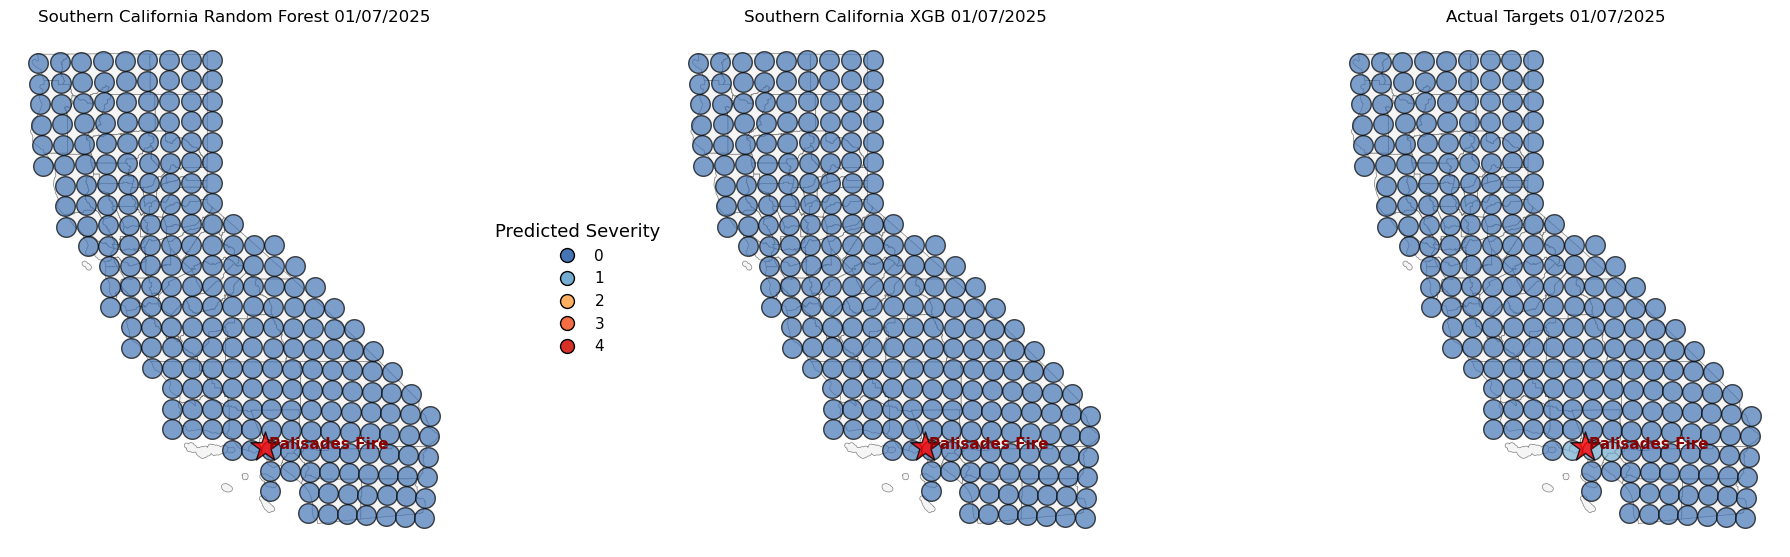

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))  # 1 row, 3 columns

# Plot into each subplot by passing in the axis
plot_map(pal_predictions, 'Prediction Damage RF', 'Palisades', ax=axes[0])
plot_map(pal_predictions, 'Prediction Damage XGB', 'Palisades', ax=axes[1])
plot_map(pal_predictions, 'Prediction Damage Actual', 'Palisades', ax=axes[2])

# Set titles if plot_map doesn't do it
axes[0].set_title('Southern California Random Forest 01/07/2025')
axes[1].set_title('Southern California XGB 01/07/2025')
axes[2].set_title('Actual Targets 01/07/2025')

plt.tight_layout()

## 3. Export File

In [16]:
pal_gdf.to_csv('../data/processed/predictions_damage.csv', index=False)
print("All datasets saved successfully to ../data/processed/")

All datasets saved successfully to ../data/processed/
